# 02 - Modelado con red neuronal y aprendizaje por refuerzo contextual

En este notebook construimos modelos deliberadamente poco transparentes para justificar después una auditoría XAI sólida.

Se entrenan dos enfoques:

1. **Red neuronal supervisada MLP** para estimar la probabilidad de morosidad grave.
2. **Política de aprendizaje por refuerzo contextual / contextual bandit**, donde cada cliente es un contexto y el modelo decide si clasificarlo como bajo o alto riesgo.

La práctica exige dos escenarios de coste:

- Escenario 1: coste falso positivo = 1, coste falso negativo = 1.
- Escenario 2: coste falso positivo = 1, coste falso negativo = 10.

Interpretación de errores:

- Falso positivo: el modelo predice `1` —cliente malo / denegar— pero realmente era `0`. Coste: se rechaza a un cliente bueno.
- Falso negativo: el modelo predice `0` —cliente bueno / conceder— pero realmente era `1`. Coste: se concede crédito a un cliente con mora grave. En el segundo escenario este error cuesta diez veces más.

In [1]:
# ==============================
# Imports
# ==============================

from __future__ import annotations

import json
import math
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import joblib

# Necesario para poder reconstruir ScaledKNNImputer al cargar
# preprocessing_objects.joblib (ver preprocessing_utils.py).
from preprocessing_utils import ScaledKNNImputer  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Para reproducibilidad. En GPU puede hacer el entrenamiento más lento, pero aquí se prioriza estabilidad.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

OUTPUT_DIR = Path("outputs")
OBJECTS_DIR = OUTPUT_DIR / "objects"
MODELS_DIR = OUTPUT_DIR / "models"
PLOTS_DIR = OUTPUT_DIR / "plots"

for p in [OUTPUT_DIR, OBJECTS_DIR, MODELS_DIR, PLOTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

Device: cpu


## 1. Carga de datos preprocesados

Este notebook asume que se ha ejecutado antes `01_EDA_Preprocesado.ipynb`. Si no existen los ficheros preprocesados, se lanza un error claro para evitar entrenar con datos sin limpiar.

In [2]:
train_preprocessed_path = OUTPUT_DIR / "preprocessed_train.csv"
preprocessing_objects_path = OBJECTS_DIR / "preprocessing_objects.joblib"

if not train_preprocessed_path.exists() or not preprocessing_objects_path.exists():
    raise FileNotFoundError(
        "No se encuentran los datos preprocesados. Ejecuta primero 01_EDA_Preprocesado.ipynb."
    )

train_df = pd.read_csv(train_preprocessed_path)
preprocessing_objects = joblib.load(preprocessing_objects_path)

TARGET = preprocessing_objects["target"]
FEATURES = preprocessing_objects["final_features"]

print("Train preprocesado:", train_df.shape)
print("Target:", TARGET)
print("N features:", len(FEATURES))

Train preprocesado: (104669, 26)
Target: SeriousDlqin2yrs
N features: 16


In [3]:
# Separamos X e y.
X = train_df[FEATURES].astype(float).copy()
y = train_df[TARGET].astype(int).copy()

print("Distribución target:")
print(y.value_counts(normalize=True).rename("pct"))

# Split holdout estratificado.
# La validación se usa para elegir thresholds y comparar modelos.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train.shape, "Validación:", X_val.shape)

Distribución target:
SeriousDlqin2yrs
0   0.9330
1   0.0670
Name: pct, dtype: float64
Train: (83735, 16) Validación: (20934, 16)


## 2. Función de coste y métricas

La métrica clave para entregar predicciones es el coste esperado bajo cada escenario.

Usaremos también métricas estándar para entender el comportamiento:

- ROC AUC: capacidad de ranking global.
- PR AUC: útil cuando la clase positiva es minoritaria.
- Recall clase 1: proporción de morosos graves detectados.
- Precision clase 1: de los marcados como morosos, cuántos lo eran.
- F1: equilibrio precision/recall.
- MCC: métrica robusta para clasificación desbalanceada.
- Balanced accuracy: media del recall de ambas clases.

In [4]:
def cost_from_predictions(y_true: np.ndarray, y_pred: np.ndarray, fp_cost: float, fn_cost: float) -> Dict[str, float]:
    """
    Calcula coste total y promedio a partir de y real y predicción binaria.

    Convención:
    - y_pred = 1 significa predecir morosidad grave / denegar crédito.
    - y_pred = 0 significa predecir no morosidad / conceder crédito.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    total_cost = fp_cost * fp + fn_cost * fn
    avg_cost = total_cost / len(y_true)
    return {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "total_cost": total_cost,
        "avg_cost": avg_cost,
    }


def find_best_threshold(y_true: np.ndarray, y_proba: np.ndarray, fp_cost: float, fn_cost: float) -> Tuple[float, pd.DataFrame]:
    """
    Busca el threshold que minimiza el coste en validación.

    No se fija 0.5 porque en problemas de riesgo el threshold óptimo depende del coste relativo.
    """
    thresholds = np.linspace(0.01, 0.99, 199)
    rows = []

    for thr in thresholds:
        pred = (y_proba >= thr).astype(int)
        cost = cost_from_predictions(y_true, pred, fp_cost=fp_cost, fn_cost=fn_cost)
        rows.append({"threshold": thr, **cost})

    table = pd.DataFrame(rows)
    best_row = table.sort_values(["avg_cost", "threshold"]).iloc[0]
    return float(best_row["threshold"]), table


def evaluate_binary_model(
    name: str,
    y_true: np.ndarray,
    y_proba: np.ndarray,
    threshold: float,
    fp_cost: float,
    fn_cost: float,
) -> Dict[str, float]:
    """Evalúa un modelo probabilístico usando un threshold concreto."""
    y_pred = (y_proba >= threshold).astype(int)
    cost = cost_from_predictions(y_true, y_pred, fp_cost=fp_cost, fn_cost=fn_cost)

    metrics = {
        "model": name,
        "threshold": threshold,
        "fp_cost": fp_cost,
        "fn_cost": fn_cost,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_1": precision_score(y_true, y_pred, zero_division=0),
        "recall_1": recall_score(y_true, y_pred, zero_division=0),
        "f1_1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        **cost,
    }
    return metrics


def print_confusion_and_report(y_true: np.ndarray, y_pred: np.ndarray):
    """Imprime matriz de confusión y classification report."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    display(pd.DataFrame(cm, index=["real_0", "real_1"], columns=["pred_0", "pred_1"]))
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

## 3. Escalado para modelos neuronales

Las redes neuronales entrenan mucho mejor cuando las variables están centradas y escaladas. Ajustamos el `StandardScaler` solo con entrenamiento y lo aplicamos a validación.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Guardamos el scaler para usarlo después en producción y XAI.
joblib.dump(scaler, OBJECTS_DIR / "model_scaler.joblib")

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)

X_train_scaled: (83735, 16)
X_val_scaled: (20934, 16)


## 4. Modelo 1: Red neuronal supervisada MLP

La MLP toma todas las variables tabulares preprocesadas y produce un logit. Tras aplicar sigmoide, obtenemos una probabilidad estimada de `SeriousDlqin2yrs = 1`.

Arquitectura:

- Capa densa 1.
- BatchNorm para estabilizar entrenamiento.
- ReLU.
- Dropout para reducir sobreajuste.
- Capa densa 2.
- BatchNorm + ReLU + Dropout.
- Capa densa 3.
- Salida binaria.

Para tratar el desbalanceo usamos `pos_weight` en `BCEWithLogitsLoss`, penalizando más los errores sobre la clase minoritaria durante el entrenamiento.

In [6]:
class CreditMLP(nn.Module):
    """
    Red neuronal feed-forward para clasificación binaria.

    Devuelve logits, no probabilidades. Para obtener probabilidades se aplica sigmoid.
    """
    def __init__(self, input_dim: int, hidden_dims: Tuple[int, int, int] = (128, 64, 32), dropout: float = 0.25):
        super().__init__()
        h1, h2, h3 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(h3, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


def make_dataloaders(X_tr, y_tr, X_va, y_va, batch_size: int = 1024):
    """Crea dataloaders de PyTorch desde arrays numpy."""
    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr.values if hasattr(y_tr, "values") else y_tr, dtype=torch.float32),
    )
    val_ds = TensorDataset(
        torch.tensor(X_va, dtype=torch.float32),
        torch.tensor(y_va.values if hasattr(y_va, "values") else y_va, dtype=torch.float32),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def predict_mlp_proba(model: nn.Module, X_array: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    """Predice probabilidades con la MLP en batches."""
    model.eval()
    probs = []
    with torch.no_grad():
        for start in range(0, len(X_array), batch_size):
            xb = torch.tensor(X_array[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            logits = model(xb)
            prob = torch.sigmoid(logits).cpu().numpy()
            probs.append(prob)
    return np.concatenate(probs)


def train_mlp(
    X_tr: np.ndarray,
    y_tr: pd.Series,
    X_va: np.ndarray,
    y_va: pd.Series,
    input_dim: int,
    lr: float = 1e-3,
    batch_size: int = 1024,
    max_epochs: int = 80,
    patience: int = 10,
) -> Tuple[CreditMLP, pd.DataFrame]:
    """
    Entrena la red neuronal con early stopping.

    El criterio de early stopping es la loss de validación.
    """
    train_loader, val_loader = make_dataloaders(X_tr, y_tr, X_va, y_va, batch_size=batch_size)

    model = CreditMLP(input_dim=input_dim).to(DEVICE)

    # pos_weight = negativos / positivos.
    n_pos = float((y_tr == 1).sum())
    n_neg = float((y_tr == 0).sum())
    pos_weight = torch.tensor([n_neg / max(n_pos, 1.0)], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val_loss = np.inf
    best_state = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))

        val_proba = predict_mlp_proba(model, X_va)
        val_auc = roc_auc_score(y_va, val_proba)
        val_pr_auc = average_precision_score(y_va, val_proba)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_roc_auc": val_auc,
            "val_pr_auc": val_pr_auc,
        })

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f}")

        if epochs_without_improvement >= patience:
            print(f"Early stopping en epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

In [7]:
mlp_model, mlp_history = train_mlp(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    input_dim=X_train_scaled.shape[1],
    lr=1e-3,
    batch_size=1024,
    max_epochs=80,
    patience=10,
)

mlp_history.tail()

Epoch 001 | train_loss=1.0310 | val_loss=0.9469 | val_auc=0.8365


Epoch 005 | train_loss=0.9463 | val_loss=0.9322 | val_auc=0.8393


Epoch 010 | train_loss=0.9372 | val_loss=0.9254 | val_auc=0.8411


Epoch 015 | train_loss=0.9357 | val_loss=0.9253 | val_auc=0.8412


Epoch 020 | train_loss=0.9294 | val_loss=0.9264 | val_auc=0.8403


Epoch 025 | train_loss=0.9309 | val_loss=0.9257 | val_auc=0.8407


Early stopping en epoch 28.


,epoch,train_loss,val_loss,val_roc_auc,val_pr_auc
23,24,0.9283,0.9256,0.8410,0.3754
24,25,0.9309,0.9257,0.8407,0.3747
25,26,0.9299,0.9286,0.8403,0.3740
26,27,0.9318,0.9263,0.8407,0.3754
27,28,0.9311,0.9281,0.8396,0.3749


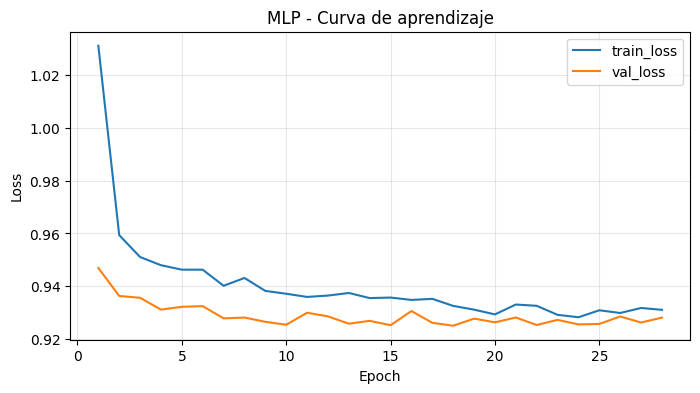

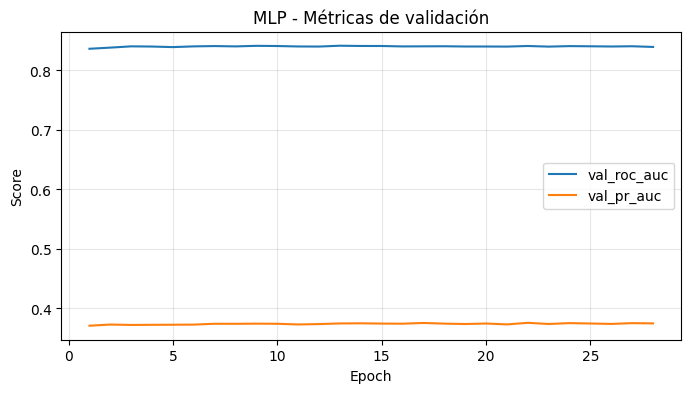

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_history["epoch"], mlp_history["train_loss"], label="train_loss")
plt.plot(mlp_history["epoch"], mlp_history["val_loss"], label="val_loss")
plt.title("MLP - Curva de aprendizaje")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(mlp_history["epoch"], mlp_history["val_roc_auc"], label="val_roc_auc")
plt.plot(mlp_history["epoch"], mlp_history["val_pr_auc"], label="val_pr_auc")
plt.title("MLP - Métricas de validación")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
mlp_val_proba = predict_mlp_proba(mlp_model, X_val_scaled)

# Optimizamos thresholds para los dos escenarios de coste.
scenarios = {
    "cost_1_1": {"fp_cost": 1, "fn_cost": 1, "output_file": "cs_produccion1.csv"},
    "cost_1_10": {"fp_cost": 1, "fn_cost": 10, "output_file": "cs_produccion2.csv"},
}

mlp_results = []
threshold_tables = {}

for scenario_name, params in scenarios.items():
    best_thr, thr_table = find_best_threshold(
        y_val.values,
        mlp_val_proba,
        fp_cost=params["fp_cost"],
        fn_cost=params["fn_cost"],
    )
    threshold_tables[f"mlp_{scenario_name}"] = thr_table
    metrics = evaluate_binary_model(
        name="MLP",
        y_true=y_val.values,
        y_proba=mlp_val_proba,
        threshold=best_thr,
        fp_cost=params["fp_cost"],
        fn_cost=params["fn_cost"],
    )
    metrics["scenario"] = scenario_name
    mlp_results.append(metrics)

mlp_results_df = pd.DataFrame(mlp_results)
mlp_results_df

,model,threshold,fp_cost,fn_cost,accuracy,balanced_accuracy,precision_1,recall_1,f1_1,mcc,roc_auc,pr_auc,tn,fp,fn,tp,total_cost,avg_cost,scenario
0,MLP,0.9405,1,1,0.9369,0.5636,0.6436,0.1326,0.2199,0.2728,0.8407,0.3745,19428,103,1217,186,1320,0.0631,cost_1_1
1,MLP,0.6089,1,10,0.8567,0.7654,0.2686,0.6600,0.3818,0.3579,0.8407,0.3745,17009,2522,477,926,7292,0.3483,cost_1_10


In [10]:
# Matrices de confusión de la MLP en cada escenario.
for _, row in mlp_results_df.iterrows():
    print("\nEscenario:", row["scenario"], "| threshold:", round(row["threshold"], 4))
    pred = (mlp_val_proba >= row["threshold"]).astype(int)
    print_confusion_and_report(y_val.values, pred)


Escenario: cost_1_1 | threshold: 0.9405


,pred_0,pred_1
real_0,19428,103
real_1,1217,186


              precision    recall  f1-score   support

           0     0.9411    0.9947    0.9671     19531
           1     0.6436    0.1326    0.2199      1403

    accuracy                         0.9369     20934
   macro avg     0.7923    0.5636    0.5935     20934
weighted avg     0.9211    0.9369    0.9171     20934


Escenario: cost_1_10 | threshold: 0.6089


,pred_0,pred_1
real_0,17009,2522
real_1,477,926


              precision    recall  f1-score   support

           0     0.9727    0.8709    0.9190     19531
           1     0.2686    0.6600    0.3818      1403

    accuracy                         0.8567     20934
   macro avg     0.6206    0.7654    0.6504     20934
weighted avg     0.9255    0.8567    0.8830     20934



## 5. Modelo 2: aprendizaje por refuerzo contextual / contextual bandit

Formulamos el problema como una decisión de un solo paso:

- **Contexto**: variables del cliente.
- **Acción 0**: clasificar como no moroso grave / conceder.
- **Acción 1**: clasificar como moroso grave / denegar.
- **Recompensa**: depende de si la decisión coincide con la etiqueta real y del coste de equivocarse.

Como tenemos histórico etiquetado, podemos simular la recompensa de ambas acciones para cada cliente. Entrenamos una política neuronal que maximiza recompensa esperada.

Este enfoque encaja con la idea de *multi-armed bandit contextual*: cada cliente es un contexto y las acciones son brazos. El modelo no se limita a estimar una probabilidad, sino que aprende una política de decisión bajo una función de coste.

In [11]:
class ContextualBanditPolicy(nn.Module):
    """
    Política neuronal para contextual bandit con dos acciones.

    Salida:
    - logits de tamaño 2: acción 0 y acción 1.
    - softmax(logits): probabilidad de elegir cada acción.
    """
    def __init__(self, input_dim: int, hidden_dims: Tuple[int, int] = (128, 64), dropout: float = 0.20):
        super().__init__()
        h1, h2 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.BatchNorm1d(h1),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.BatchNorm1d(h2),
            nn.Dropout(dropout),
            nn.Linear(h2, 2),
        )

    def forward(self, x):
        return self.net(x)


def reward_matrix(y_true: torch.Tensor, fp_cost: float, fn_cost: float) -> torch.Tensor:
    """
    Matriz de recompensas R para acciones [0, 1].

    Acción 0: predecir 0.
    Acción 1: predecir 1.

    Si la acción acierta: +1.
    Si falla:
    - acción 1 cuando y=0 -> falso positivo -> -fp_cost.
    - acción 0 cuando y=1 -> falso negativo -> -fn_cost.
    """
    y_true = y_true.long()
    r0 = torch.where(y_true == 0, torch.tensor(1.0, device=y_true.device), torch.tensor(-float(fn_cost), device=y_true.device))
    r1 = torch.where(y_true == 1, torch.tensor(1.0, device=y_true.device), torch.tensor(-float(fp_cost), device=y_true.device))
    return torch.stack([r0, r1], dim=1)


def train_contextual_bandit(
    X_tr: np.ndarray,
    y_tr: pd.Series,
    X_va: np.ndarray,
    y_va: pd.Series,
    fp_cost: float,
    fn_cost: float,
    input_dim: int,
    lr: float = 1e-3,
    batch_size: int = 1024,
    max_epochs: int = 80,
    patience: int = 10,
) -> Tuple[ContextualBanditPolicy, pd.DataFrame]:
    """
    Entrena una política de bandit maximizando recompensa esperada.

    La loss es la recompensa esperada negativa:
        loss = - mean(sum_a pi(a|x) * R(a, y))
    """
    train_loader, val_loader = make_dataloaders(X_tr, y_tr, X_va, y_va, batch_size=batch_size)
    model = ContextualBanditPolicy(input_dim=input_dim).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val_reward = -np.inf
    best_state = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_rewards = []
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            probs = F.softmax(logits, dim=1)
            rewards = reward_matrix(yb, fp_cost=fp_cost, fn_cost=fn_cost)
            expected_reward = (probs * rewards).sum(dim=1).mean()
            loss = -expected_reward
            loss.backward()
            optimizer.step()

            train_rewards.append(expected_reward.item())
            train_losses.append(loss.item())

        model.eval()
        val_rewards = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = model(xb)
                probs = F.softmax(logits, dim=1)
                rewards = reward_matrix(yb, fp_cost=fp_cost, fn_cost=fn_cost)
                expected_reward = (probs * rewards).sum(dim=1).mean()
                val_rewards.append(expected_reward.item())

        train_reward = float(np.mean(train_rewards))
        val_reward = float(np.mean(val_rewards))
        train_loss = float(np.mean(train_losses))

        val_action_proba = predict_bandit_action1_proba(model, X_va)
        val_actions = (val_action_proba >= 0.5).astype(int)
        val_cost = cost_from_predictions(y_va.values, val_actions, fp_cost=fp_cost, fn_cost=fn_cost)["avg_cost"]

        history.append({
            "epoch": epoch,
            "train_expected_reward": train_reward,
            "val_expected_reward": val_reward,
            "train_loss": train_loss,
            "val_avg_cost": val_cost,
        })

        if val_reward > best_val_reward + 1e-5:
            best_val_reward = val_reward
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_reward={train_reward:.4f} | val_reward={val_reward:.4f} | val_cost={val_cost:.4f}")

        if epochs_without_improvement >= patience:
            print(f"Early stopping en epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def predict_bandit_action1_proba(model: nn.Module, X_array: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    """Devuelve probabilidad de acción 1 según la política del bandit."""
    model.eval()
    probs_out = []
    with torch.no_grad():
        for start in range(0, len(X_array), batch_size):
            xb = torch.tensor(X_array[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            logits = model(xb)
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            probs_out.append(probs)
    return np.concatenate(probs_out)

In [12]:
bandit_models = {}
bandit_histories = {}
bandit_results = []

for scenario_name, params in scenarios.items():
    print("\n==============================")
    print("Entrenando bandit para", scenario_name, params)
    print("==============================")

    bandit_model, bandit_history = train_contextual_bandit(
        X_train_scaled,
        y_train,
        X_val_scaled,
        y_val,
        fp_cost=params["fp_cost"],
        fn_cost=params["fn_cost"],
        input_dim=X_train_scaled.shape[1],
        lr=1e-3,
        batch_size=1024,
        max_epochs=80,
        patience=10,
    )

    bandit_models[scenario_name] = bandit_model
    bandit_histories[scenario_name] = bandit_history

    bandit_val_proba = predict_bandit_action1_proba(bandit_model, X_val_scaled)
    # En una política bandit usamos la acción más probable. Equivale a threshold 0.5.
    metrics = evaluate_binary_model(
        name=f"ContextualBandit_{scenario_name}",
        y_true=y_val.values,
        y_proba=bandit_val_proba,
        threshold=0.5,
        fp_cost=params["fp_cost"],
        fn_cost=params["fn_cost"],
    )
    metrics["scenario"] = scenario_name
    bandit_results.append(metrics)

bandit_results_df = pd.DataFrame(bandit_results)
bandit_results_df


Entrenando bandit para cost_1_1 {'fp_cost': 1, 'fn_cost': 1, 'output_file': 'cs_produccion1.csv'}


Epoch 001 | train_reward=0.5488 | val_reward=0.7306 | val_cost=0.1158


Epoch 005 | train_reward=0.7950 | val_reward=0.7907 | val_cost=0.1035


Epoch 010 | train_reward=0.8263 | val_reward=0.8193 | val_cost=0.0896


Epoch 015 | train_reward=0.8283 | val_reward=0.8199 | val_cost=0.0894


...

Epoch 020 | train_reward=0.5233 | val_reward=0.5124 | val_cost=0.3816


Epoch 025 | train_reward=0.5238 | val_reward=0.5124 | val_cost=0.3796


Epoch 030 | train_reward=0.5250 | val_reward=0.5105 | val_cost=0.3804


Early stopping en epoch 32.


,model,threshold,fp_cost,fn_cost,accuracy,balanced_accuracy,precision_1,recall_1,f1_1,mcc,roc_auc,pr_auc,tn,fp,fn,tp,total_cost,avg_cost,scenario
0,ContextualBandit_cost_1_1,0.5000,1,1,0.9115,0.5666,0.2562,0.1682,0.2031,0.1623,0.4551,0.1088,18846,685,1167,236,1852,0.0885,cost_1_1
1,ContextualBandit_cost_1_10,0.5000,1,10,0.8943,0.7419,0.3312,0.5659,0.4179,0.3800,0.7872,0.2904,17928,1603,609,794,7693,0.3675,cost_1_10


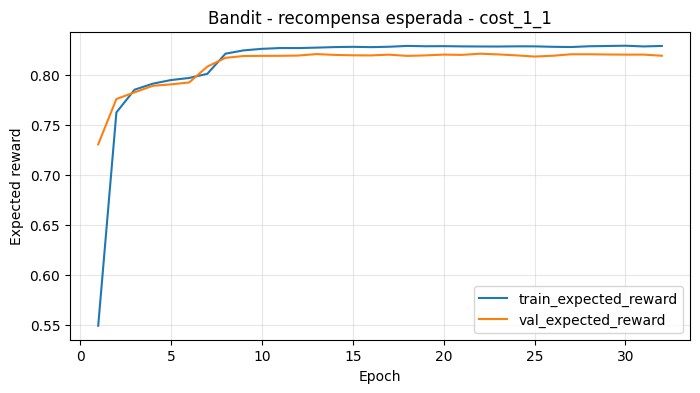

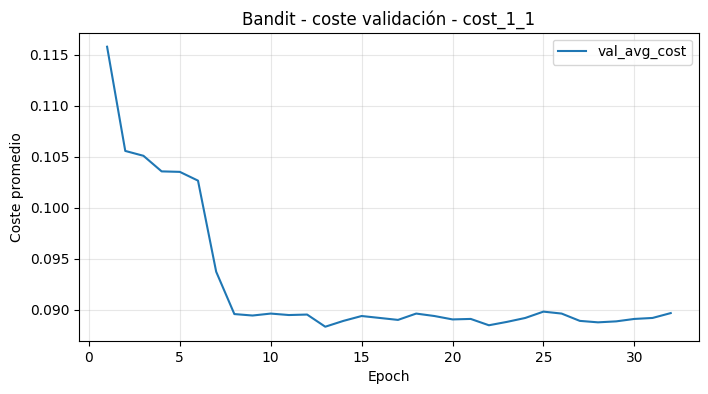

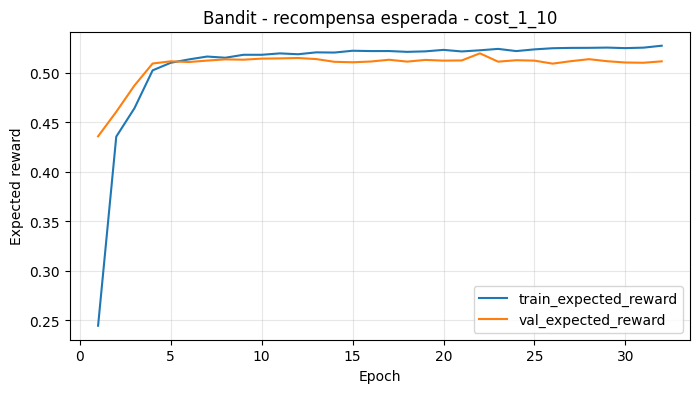

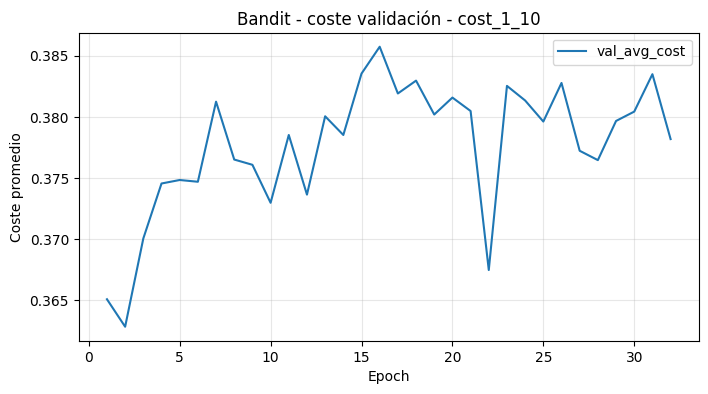

In [13]:
for scenario_name, hist in bandit_histories.items():
    plt.figure(figsize=(8, 4))
    plt.plot(hist["epoch"], hist["train_expected_reward"], label="train_expected_reward")
    plt.plot(hist["epoch"], hist["val_expected_reward"], label="val_expected_reward")
    plt.title(f"Bandit - recompensa esperada - {scenario_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Expected reward")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(hist["epoch"], hist["val_avg_cost"], label="val_avg_cost")
    plt.title(f"Bandit - coste validación - {scenario_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Coste promedio")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [14]:
# Matrices de confusión de los bandits.
for scenario_name, model in bandit_models.items():
    params = scenarios[scenario_name]
    prob = predict_bandit_action1_proba(model, X_val_scaled)
    pred = (prob >= 0.5).astype(int)
    print("\nEscenario:", scenario_name)
    print_confusion_and_report(y_val.values, pred)
    display(pd.DataFrame([cost_from_predictions(y_val.values, pred, params["fp_cost"], params["fn_cost"])]))


Escenario: cost_1_1


,pred_0,pred_1
real_0,18846,685
real_1,1167,236


              precision    recall  f1-score   support

           0     0.9417    0.9649    0.9532     19531
           1     0.2562    0.1682    0.2031      1403

    accuracy                         0.9115     20934
   macro avg     0.5990    0.5666    0.5781     20934
weighted avg     0.8957    0.9115    0.9029     20934



,tn,fp,fn,tp,total_cost,avg_cost
0,18846,685,1167,236,1852,0.0885



Escenario: cost_1_10


,pred_0,pred_1
real_0,17928,1603
real_1,609,794


              precision    recall  f1-score   support

           0     0.9671    0.9179    0.9419     19531
           1     0.3312    0.5659    0.4179      1403

    accuracy                         0.8943     20934
   macro avg     0.6492    0.7419    0.6799     20934
weighted avg     0.9245    0.8943    0.9068     20934



,tn,fp,fn,tp,total_cost,avg_cost
0,17928,1603,609,794,7693,0.3675


## 6. Comparación final en validación

Comparamos MLP y bandit por escenario. La selección del modelo final se hace minimizando el coste promedio de validación bajo el escenario correspondiente.

Es posible que el mejor modelo no sea el mismo para los dos escenarios. Eso es razonable: cuando el falso negativo cuesta 10, el modelo debe ser más agresivo detectando la clase 1.

In [15]:
all_results = pd.concat([mlp_results_df, bandit_results_df], ignore_index=True)
all_results = all_results.sort_values(["scenario", "avg_cost"])
all_results

,model,threshold,fp_cost,fn_cost,accuracy,balanced_accuracy,precision_1,recall_1,f1_1,mcc,roc_auc,pr_auc,tn,fp,fn,tp,total_cost,avg_cost,scenario
0,MLP,0.9405,1,1,0.9369,0.5636,0.6436,0.1326,0.2199,0.2728,0.8407,0.3745,19428,103,1217,186,1320,0.0631,cost_1_1
2,ContextualBandit_cost_1_1,0.5000,1,1,0.9115,0.5666,0.2562,0.1682,0.2031,0.1623,0.4551,0.1088,18846,685,1167,236,1852,0.0885,cost_1_1
1,MLP,0.6089,1,10,0.8567,0.7654,0.2686,0.6600,0.3818,0.3579,0.8407,0.3745,17009,2522,477,926,7292,0.3483,cost_1_10
3,ContextualBandit_cost_1_10,0.5000,1,10,0.8943,0.7419,0.3312,0.5659,0.4179,0.3800,0.7872,0.2904,17928,1603,609,794,7693,0.3675,cost_1_10


In [16]:
# Seleccionamos el mejor modelo por escenario.
best_by_scenario = all_results.sort_values("avg_cost").groupby("scenario", as_index=False).first()
best_by_scenario

,scenario,model,threshold,fp_cost,fn_cost,accuracy,balanced_accuracy,precision_1,recall_1,f1_1,mcc,roc_auc,pr_auc,tn,fp,fn,tp,total_cost,avg_cost
0,cost_1_1,MLP,0.9405,1,1,0.9369,0.5636,0.6436,0.1326,0.2199,0.2728,0.8407,0.3745,19428,103,1217,186,1320,0.0631
1,cost_1_10,MLP,0.6089,1,10,0.8567,0.7654,0.2686,0.6600,0.3818,0.3579,0.8407,0.3745,17009,2522,477,926,7292,0.3483


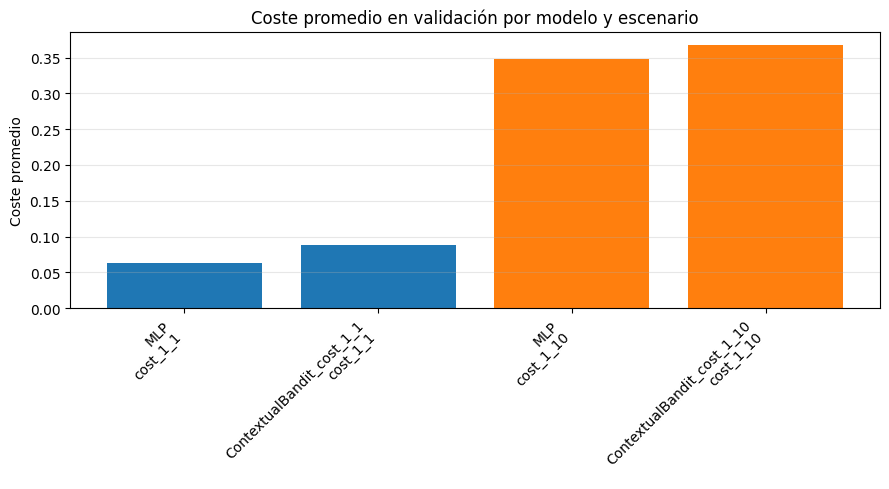

In [17]:
plt.figure(figsize=(9, 5))
for scenario_name in all_results["scenario"].unique():
    temp = all_results[all_results["scenario"] == scenario_name]
    plt.bar(temp["model"] + "\n" + scenario_name, temp["avg_cost"])
plt.title("Coste promedio en validación por modelo y escenario")
plt.ylabel("Coste promedio")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Reentrenamiento final con train + validación

Una vez elegidos thresholds y modelos, reentrenamos los modelos sobre todo `cs_construccion.csv` para aprovechar todos los datos antes de predecir producción.

Mantenemos los thresholds aprendidos en validación, porque son parte de la política de decisión. En un proyecto real se conservaría un conjunto de test separado; aquí el objetivo es generar predicciones para producción con la mejor información disponible.

In [18]:
# Escalamos todo el dataset de construcción con un scaler final.
final_scaler = StandardScaler()
X_all_scaled = final_scaler.fit_transform(X)
y_all = y.copy()

joblib.dump(final_scaler, OBJECTS_DIR / "final_model_scaler.joblib")

# Para tener early stopping, dentro del reentrenamiento hacemos un pequeño split interno.
X_tr_full, X_es, y_tr_full, y_es = train_test_split(
    X_all_scaled,
    y_all,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

final_models = {}
model_metadata = {
    "target": TARGET,
    "features": FEATURES,
    "scenarios": scenarios,
    "validation_results": all_results.to_dict(orient="records"),
    "best_by_scenario": best_by_scenario.to_dict(orient="records"),
}

# Reentrenamos MLP final.
print("Reentrenando MLP final...")
final_mlp, final_mlp_history = train_mlp(
    X_tr_full,
    y_tr_full,
    X_es,
    y_es,
    input_dim=X_all_scaled.shape[1],
    lr=1e-3,
    batch_size=1024,
    max_epochs=80,
    patience=10,
)
final_models["MLP"] = final_mlp

# Reentrenamos bandits finales por escenario.
for scenario_name, params in scenarios.items():
    print("\nReentrenando bandit final para", scenario_name)
    final_bandit, final_bandit_history = train_contextual_bandit(
        X_tr_full,
        y_tr_full,
        X_es,
        y_es,
        fp_cost=params["fp_cost"],
        fn_cost=params["fn_cost"],
        input_dim=X_all_scaled.shape[1],
        lr=1e-3,
        batch_size=1024,
        max_epochs=80,
        patience=10,
    )
    final_models[f"ContextualBandit_{scenario_name}"] = final_bandit

Reentrenando MLP final...


Epoch 001 | train_loss=1.0346 | val_loss=0.9347 | val_auc=0.8439


Epoch 005 | train_loss=0.9474 | val_loss=0.9121 | val_auc=0.8490


Epoch 010 | train_loss=0.9367 | val_loss=0.9081 | val_auc=0.8491


Epoch 015 | train_loss=0.9343 | val_loss=0.9090 | val_auc=0.8486


...

Epoch 010 | train_reward=0.5189 | val_reward=0.5199 | val_cost=0.3729


Epoch 015 | train_reward=0.5208 | val_reward=0.5204 | val_cost=0.3784


Epoch 020 | train_reward=0.5237 | val_reward=0.5216 | val_cost=0.3753


Epoch 025 | train_reward=0.5253 | val_reward=0.5193 | val_cost=0.3794


Early stopping en epoch 27.


In [19]:
# Guardamos modelos PyTorch y metadatos.
torch.save({
    "model_type": "MLP",
    "input_dim": X_all_scaled.shape[1],
    "hidden_dims": (128, 64, 32),
    "dropout": 0.25,
    "state_dict": final_models["MLP"].state_dict(),
}, MODELS_DIR / "final_mlp.pt")

for scenario_name in scenarios.keys():
    model_name = f"ContextualBandit_{scenario_name}"
    torch.save({
        "model_type": "ContextualBanditPolicy",
        "input_dim": X_all_scaled.shape[1],
        "hidden_dims": (128, 64),
        "dropout": 0.20,
        "state_dict": final_models[model_name].state_dict(),
    }, MODELS_DIR / f"final_bandit_{scenario_name}.pt")

# Thresholds óptimos para la MLP por escenario.
mlp_thresholds = {
    row["scenario"]: float(row["threshold"])
    for _, row in mlp_results_df.iterrows()
}
model_metadata["mlp_thresholds"] = mlp_thresholds

# Indicamos qué modelo se usará por defecto en cada escenario.
# Si el mejor en validación es una fila MLP, se usa final_mlp + threshold.
# Si es bandit, se usa el bandit del escenario.
selected_models = {}
for _, row in best_by_scenario.iterrows():
    scenario = row["scenario"]
    model = row["model"]
    if model == "MLP":
        selected_models[scenario] = {
            "model_family": "MLP",
            "model_file": "final_mlp.pt",
            "threshold": mlp_thresholds[scenario],
        }
    else:
        selected_models[scenario] = {
            "model_family": "ContextualBanditPolicy",
            "model_file": f"final_bandit_{scenario}.pt",
            "threshold": 0.5,
        }

model_metadata["selected_models"] = selected_models

joblib.dump(model_metadata, MODELS_DIR / "model_metadata.joblib")
all_results.to_csv(OUTPUT_DIR / "validation_results.csv", index=False)
mlp_history.to_csv(OUTPUT_DIR / "mlp_history_validation.csv", index=False)
final_mlp_history.to_csv(OUTPUT_DIR / "final_mlp_history.csv", index=False)

for name, table in threshold_tables.items():
    table.to_csv(OUTPUT_DIR / f"threshold_search_{name}.csv", index=False)

print("Modelos guardados en:", MODELS_DIR.resolve())
print("Modelo seleccionado por escenario:")
print(json.dumps(selected_models, indent=2))

Modelos guardados en: /home/claude/work/outputs/models
Modelo seleccionado por escenario:
{
  "cost_1_1": {
    "model_family": "MLP",
    "model_file": "final_mlp.pt",
    "threshold": 0.9405050505050505
  },
  "cost_1_10": {
    "model_family": "MLP",
    "model_file": "final_mlp.pt",
    "threshold": 0.6088888888888889
  }
}


## 8. Conclusiones del modelado

Aspectos clave para comentar:

1. Se ha entrenado una red neuronal supervisada que estima la probabilidad de mora grave.
2. Se ha entrenado un contextual bandit que aprende una política de decisión dependiente de costes.
3. El threshold de decisión no se fija en 0.5 para la MLP: se optimiza según coste.
4. En el escenario `FP=1, FN=10`, el modelo debería tender a reducir falsos negativos, aunque eso aumente falsos positivos.
5. El modelo final por escenario queda guardado para producción y para el análisis XAI.

El siguiente notebook audita estos modelos de caja negra mediante SHAP, modelo subrogado y contrafactuales.